## RiverCast: Forecasting Marikina River Level using BiDirectional Transformer

### Import Dataset and Libraries

In [4]:
import time
import calendar
from datetime import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import block_reduce
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error

import copy
import math
import torch
import torch.nn as nn

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')  # configure GPU utilization

In [5]:
df = pd.read_csv('riverlevel.csv')

### Prepare the Dataset

To make sure that our data types are suited for learning, the researchers converted 'Month', 'Day', and 'Year' columns to timestamps; converted all numerical values into double precision floating numbers; filled in NULL values; and resampled the data to 24-hour intervals.

In [6]:
# convert month name to integer
month_dict = dict((v, k) for k, v in enumerate(calendar.month_name))
df['Month'] = df['Month'].map(month_dict)

# create datetime column
df[['Year', 'Month', 'Day', 'Hour']] = df[['Year', 'Month', 'Day', 'Hour']].astype(int)
df['Hour'] = df['Hour'].apply(lambda x: x if x < 24 else 0)

# convert year, month, day, and hour columns into timestamp
df['Datetime'] = df[['Year', 'Month', 'Day', 'Hour']].apply(lambda row: datetime(row['Year'], row['Month'], row['Day'], row['Hour']).isoformat(), axis=1)
df["Datetime"] = pd.to_datetime(df["Datetime"], format='ISO8601')

# assign timestamps as the data frame index
df.index = df["Datetime"]
df = df.drop(['Datetime'], axis=1)

# select the parameters
df = df[['Waterlevel', 'Waterlevel.1', 'Waterlevel.2', 'RF-Intensity', 'RF-Intensity.1', 'Precipitation', 'Humidity', 'Temperature']] 
df = df.astype(np.float64)  # convert parameters into a double precision floating number

# fill in missing values using linear interpolation
df = df.interpolate(method='linear', limit_direction='forward')
df = df.resample('24H').max()  # resample dataset using the max value for each 24-hours

df.head(10)  # display data frame

,Waterlevel,Waterlevel.1,Waterlevel.2,RF-Intensity,RF-Intensity.1,Precipitation,Humidity,Temperature
Datetime,,,,,,,,
2012-01-01,15.94,12.53,21.97,0.0,0.0,0.08,18.01,28.69
2012-01-02,15.86,12.52,21.96,0.0,4.0,0.41,17.88,28.08
2012-01-03,15.94,12.51,21.94,7.0,4.0,1.64,17.88,27.39
2012-01-04,16.00,12.50,22.03,0.0,0.0,1.41,17.82,27.20
2012-01-05,15.85,12.49,22.01,0.0,0.0,0.35,16.36,26.10
2012-01-06,15.84,12.49,21.96,0.0,4.0,1.41,17.15,27.24
2012-01-07,15.86,12.48,21.94,1.0,0.0,1.50,18.49,27.40
2012-01-08,16.01,12.46,22.09,7.0,5.0,1.99,18.31,25.32
2012-01-09,15.88,12.45,22.10,0.0,1.0,0.65,17.82,27.19


### Clean Dataset

The researchers reduced the outliers in the dataset using moving average smoothing. Note the we only reduced the outliers but not completely remove them to enable the model learn about flooding incidents.

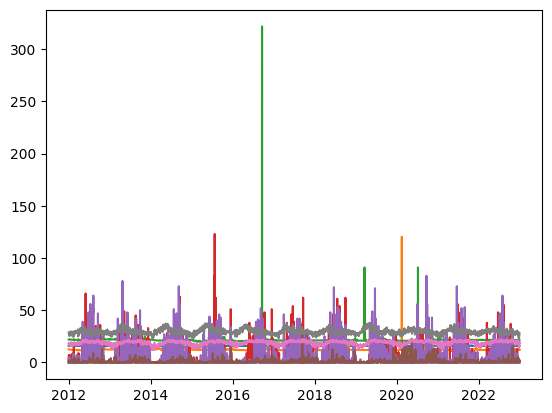

In [7]:
plt.plot(df)
plt.show()

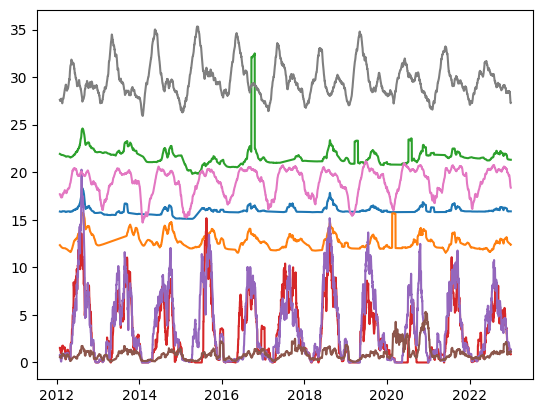

In [8]:
df = df.rolling(30).mean().dropna()

plt.plot(df)
plt.show()

### Normalize Dataset

In [9]:
scaler = MinMaxScaler()
scaler.fit(df)

normalized_data = scaler.transform(df)

normalized_data.shape

(3989, 8)

### Prepare Dataset Batches

Time-series data from January 2012 to December 2019 will serve as the training dataset while the data from January 2020 to December 2022 will serve as the test dataset.

In [10]:
train_ds = normalized_data[:2922]
test_ds = normalized_data[-1460:]

print(train_ds.shape)
print(test_ds.shape)

(2922, 8)
(1460, 8)


In [11]:
class TimeSeriesDataset(torch.utils.data.Dataset):
    def __init__(self, data, seq_len):
        self.data = data
        self.seq_len = seq_len
        
    def __getitem__(self, index):
        in_start = index
        in_end = in_start + self.seq_len
        out_start = in_end
        out_end = out_start + self.seq_len
        
        inputs = self.data[in_start:in_end]
        labels = self.data[out_start:out_end]
        
        return inputs, labels
    
    def __len__(self):
        return len(self.data) - (self.seq_len * 2) + 1

In [12]:
BATCH_SIZE = 64
SEQ_LEN = 730

train_dataset = TimeSeriesDataset(data=train_ds, seq_len=SEQ_LEN)
test_dataset = TimeSeriesDataset(data=test_ds, seq_len=SEQ_LEN)

train_dataloader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False
)

test_dataloader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False
)

print(len(train_dataset))
print(len(test_dataset))


1463
1


### Build the Model

In [13]:
PRED_SIZE = 8
D_MODEL = 8
NUM_HEADS = 4
NUM_LAYERS = 2
D_FF = 2048
MAX_SEQ_LEN = 730 
DROPOUT = 0.10

#### Attention Mechanism

In the context of forecasting, a multi-head attention mechanism allows the model to weigh the importance of different time points in a time period thus allowing the model to capture the relationship between past events and current events. The attention scores are calculated by comparing the input sequence (after linear projection) against itself or against a query vector. 

Notice that unlike the autoregressive transformer, the attention mechanism have no mask because it aims to understand how past events affects current events and vice versa to produce forecast. Autoregressive transformer, on the other hand, only focuses on understanding how past events affects current events but not the other way around.

In [14]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        
    def scaled_dot_product_attention(self, Q, K, V):
        attn_scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        attn_probs = torch.softmax(attn_scores, dim=-1)
        output = torch.matmul(attn_probs, V)
        
        return attn_probs, output
        
    def split_heads(self, x):
        batch_size, seq_length, d_model = x.size()
        return x.view(batch_size, seq_length, self.num_heads, self.d_k).transpose(1, 2)
        
    def combine_heads(self, x):
        batch_size, _, seq_length, d_k = x.size()
        return x.transpose(1, 2).contiguous().view(batch_size, seq_length, self.d_model)
        
    def forward(self, Q, K, V):
        Q = self.split_heads(self.W_q(Q))
        K = self.split_heads(self.W_k(K))
        V = self.split_heads(self.W_v(V))
        
        attn_scores, attn_output = self.scaled_dot_product_attention(Q, K, V)
        output = self.W_o(self.combine_heads(attn_output))
        return attn_scores, output

#### Positional Encoding

Unlike human brains, neural networks are not aware of order. It cannot distinguish past values from future values. That is why, the purpose of positional encoding is to help the model distinguish between different elements in a sequence and understand the sequential order of data.

In [15]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_seq_length=1024):
        super(PositionalEncoding, self).__init__()
        
        pe = torch.zeros(max_seq_length, d_model)
        position = torch.arange(0, max_seq_length, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        
        self.register_buffer('pe', pe.unsqueeze(0))
        
    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

#### Feed Forward Network

Feed Forward Network is a fundamental type of artificial neural network. In the context of transformer models, the feed forward network aims to learn the relationship between the temporal features and the forecasted values.

In [16]:
class PositionWiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PositionWiseFeedForward, self).__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))

#### Encoder Layer

Unlike a decoder layer, the encoder layer looks at the sequence in both directions (bidirectionally) to learn how past observations influence future predictions and vice versa. Its output is not autogregressive rather, it outputs the next time period without overlapping with the current time period. The encoder layer is the combination of unmasked attention mechanism, positional encoding, and a feed forward network.

In [17]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.feed_forward = PositionWiseFeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x):
        attn_scores, attn_output = self.self_attn(x, x, x)
        x = self.norm1(x + self.dropout(attn_output))
        ff_output = self.feed_forward(x)
        x = self.norm2(x + self.dropout(ff_output))
        return attn_scores, x

In [18]:
class Transformer(nn.Module):
    def __init__(self, pred_size, d_model, num_heads, num_layers, d_ff, dropout):
        super(Transformer, self).__init__()
        self.positional_encoding = PositionalEncoding(d_model)
        self.encoder_layers = nn.ModuleList([EncoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])
        self.fc = nn.Linear(d_model, pred_size)
        self.sigmoid = nn.Sigmoid()
        self.dropout = nn.Dropout(dropout)

    def forward(self, tgt):
        tgt_embedded = self.dropout(self.positional_encoding(tgt))

        enc_output = tgt_embedded
        for enc_layer in self.encoder_layers:
            attn_scores, enc_output = enc_layer(enc_output)

        output = self.sigmoid(self.fc(enc_output))
        return attn_scores, output

### Train Transformer Module

In [19]:
encoder = Transformer(
    pred_size=PRED_SIZE,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    d_ff=D_FF,
    dropout=DROPOUT
).float()

encoder.to(device)

device

device(type='cuda', index=0)

In [20]:
encoder.eval()

sample = np.reshape(test_ds[:MAX_SEQ_LEN], (1, MAX_SEQ_LEN, D_MODEL))
output = torch.from_numpy(sample).float().to(device)
scores, output = encoder(output)
output = output.detach().cpu().numpy()
scores = scores.detach().cpu().numpy()

print(output.shape)
print(scores.shape)

(1, 730, 8)
(1, 4, 730, 730)


In [22]:
def train_encoder(train_dataloader, val_dataloader, epochs=10, es_value=0.010):
    time_now = time.time()
    train_steps = len(train_dataloader)
    train_epochs = epochs

    # initialize optimizer that will adjust the model's weights and biases during training
    model_optim = torch.optim.Adam(encoder.parameters(), lr=0.001)
    
    # initialize loss function that will determine the error between the actual values and forecasted values
    loss_fn = torch.nn.MSELoss()

    for epoch in range(train_epochs):
        iter_count = 0
        train_loss = []

        encoder.train()
        epoch_time = time.time()
        for i, (inputs, labels) in enumerate(train_dataloader):
            iter_count += 1
            model_optim.zero_grad()  # reset gradients
            
            batch_x = inputs.float().to(device)  # convert values to float and send to GPU
            batch_y = labels.float().to(device)  # convert values to float and send to GPU

            scores, outputs = encoder(batch_x)

            loss = loss_fn(outputs, batch_y)
            train_loss.append(loss.item())

            loss.backward()  # compute gradients
            model_optim.step()  # update model parameters
            
            if (i + 1) % 10 == 0:
                print("\titers: {0}, epoch: {1} | loss: {2:.7f}".format(i + 1, epoch + 1, loss.item()))
                speed = (time.time() - time_now) / iter_count
                left_time = speed * ((train_epochs - epoch) * train_steps - i)
                print('\tspeed: {:.4f}s/iter; left time: {:.4f}s'.format(speed, left_time))
                iter_count = 0
                time_now = time.time() 

        print("Epoch: {} cost time: {}".format(epoch + 1, time.time() - epoch_time))
        train_loss = np.average(train_loss)
        
        # evaluate model
        val_loss = []
        encoder.eval()
        with torch.no_grad():
            for i, (inputs, labels) in enumerate(val_dataloader):
                batch_x = inputs.float().to(device)
                batch_y = labels.float()

                scores, outputs = encoder(batch_x)
                outputs = outputs.detach().cpu()

                loss = loss_fn(outputs, batch_y)

                val_loss.append(loss)
        val_loss = np.average(val_loss)
        
        print("Epoch: {0}, Steps: {1} | Train Loss: {2:.7f} Validation Loss: {3:.7f}".format(epoch + 1, train_steps, train_loss, val_loss))
        
        # stop training upon reaching the optimal accuracy to avoid over fitting
        if val_loss < es_value:
            break
        
        encoder.train()
        
    torch.save(encoder.state_dict(), 'encoder.pth')  # save model

In [23]:
train_encoder(train_dataloader, test_dataloader, epochs=20, es_value=0.010)

	iters: 10, epoch: 1 | loss: 0.0515063
	speed: 1.5466s/iter; left time: 697.5153s
	iters: 20, epoch: 1 | loss: 0.0457317
	speed: 1.3609s/iter; left time: 600.1361s
Epoch: 1 cost time: 30.707404851913452
Epoch: 1, Steps: 23 | Train Loss: 0.0565315 Validation Loss: 0.0322924
	iters: 10, epoch: 2 | loss: 0.0428436
	speed: 1.7333s/iter; left time: 741.8632s
	iters: 20, epoch: 2 | loss: 0.0392527
	speed: 1.3192s/iter; left time: 551.4078s
Epoch: 2 cost time: 29.638861894607544
Epoch: 2, Steps: 23 | Train Loss: 0.0452035 Validation Loss: 0.0257149
	iters: 10, epoch: 3 | loss: 0.0366307
	speed: 1.6937s/iter; left time: 685.9288s
	iters: 20, epoch: 3 | loss: 0.0350053
	speed: 1.3164s/iter; left time: 519.9889s
Epoch: 3 cost time: 29.188766956329346
Epoch: 3, Steps: 23 | Train Loss: 0.0392936 Validation Loss: 0.0216966
	iters: 10, epoch: 4 | loss: 0.0327405
	speed: 1.6767s/iter; left time: 640.5135s
	iters: 20, epoch: 4 | loss: 0.0326241
	speed: 1.3142s/iter; left time: 488.8865s
Epoch: 4 cost 

### Test Model

In [21]:
encoder.load_state_dict(torch.load('encoder.pth'))

<All keys matched successfully>

In [22]:
encoder.eval()

inputs, labels = [(inputs, labels) for _, (inputs, labels) in enumerate(test_dataloader)][0]

print(inputs.shape)
print(labels.shape)

torch.Size([1, 730, 8])
torch.Size([1, 730, 8])


In [23]:
x_test = inputs.float().to(device)

attn_scores, y_test = encoder(x_test)
y_test = torch.squeeze(y_test, dim=0)
y_test = y_test.detach().cpu().numpy()
y_test = y_test[-360:]
y_test = scaler.inverse_transform(y_test)

ground = torch.squeeze(labels, dim=0)
ground = ground.numpy()
ground = ground[-360:]
ground = scaler.inverse_transform(ground)

mean_absolute_error(ground, y_test)

0.7148355033683549

#### Visualize Forecast

In [24]:
def plot_forecast(pred, true):
    forecast_df = pd.DataFrame({
        'prediction': pred,
        'ground': true
    }, index=df.index[-360:])
    
    plt.plot(forecast_df)
    plt.show()

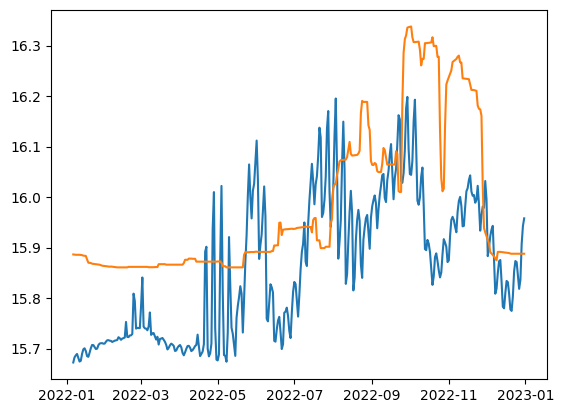

In [25]:
plot_forecast(y_test[:, 0], ground[:, 0])

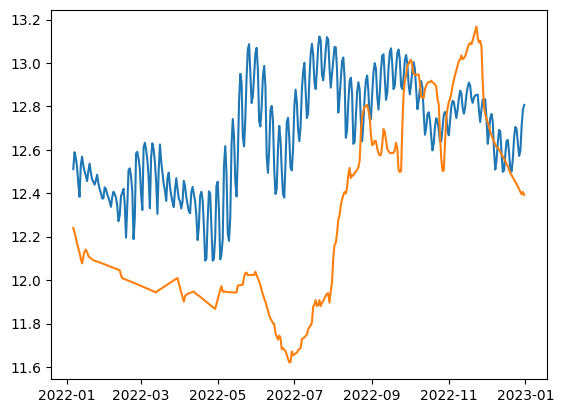

In [26]:
plot_forecast(y_test[:, 1], ground[:, 1])

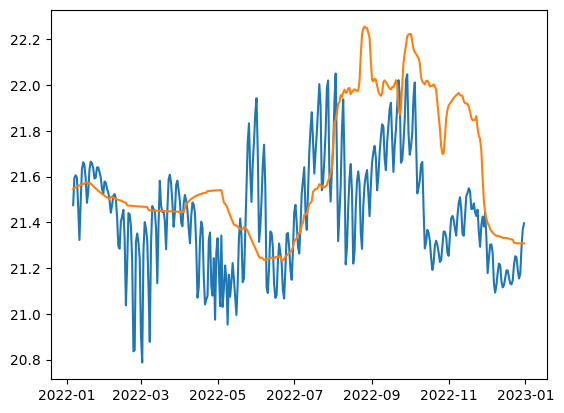

In [27]:
plot_forecast(y_test[:, 2], ground[:, 2])

#### Visualize Attention Scores

In [28]:
def plot_attention_head(attention):
    ax = plt.gca()
    
    # plot scores
    attention = attention[10:]
    attention = block_reduce(attention, (90, 90), np.mean)
    ax.matshow(attention)
    
    # plot labels
    dates = ['2021 Q1', '2021 Q2', '2021 Q3', '2021 Q4', '2022 Q1', '2022 Q2', '2022 Q3', '2022 Q4']
    ax.set_xticks(range(len(dates)))
    ax.set_yticks(range(len(dates)))

    ax.set_xticklabels(dates, rotation=90)
    ax.set_yticklabels(dates)
    plt.show()

In [29]:
attn_scores =  torch.squeeze(attn_scores, dim=0)
attn_scores = attn_scores.detach().cpu().numpy()
attn_scores.shape

(4, 730, 730)

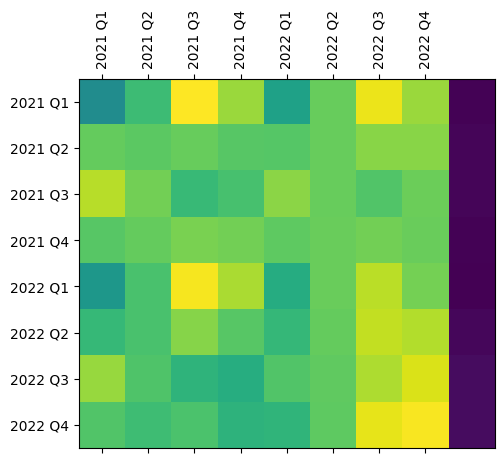

In [30]:
plot_attention_head(attn_scores[0])    

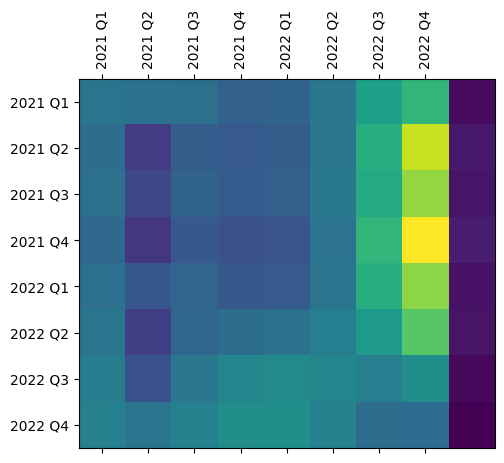

In [31]:
plot_attention_head(attn_scores[1])    

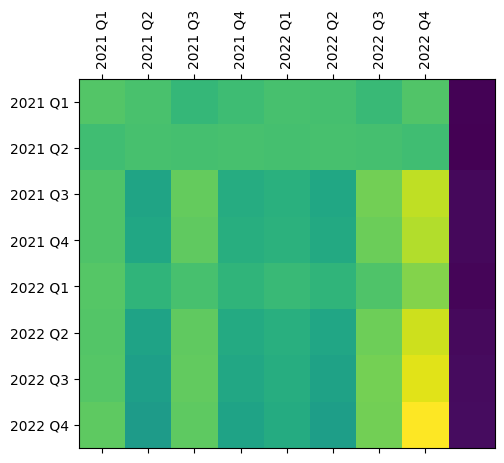

In [32]:
plot_attention_head(attn_scores[2])    

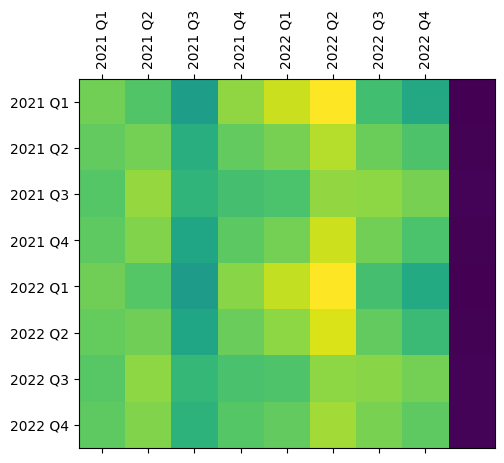

In [33]:
plot_attention_head(attn_scores[3])    